# ML - Ephyrae Appearance Prediction

**Goal:** Predict ephyrae appearance for well-documented species (Aurelia labiata) using polyp count, temperature, and context events (repiquage, temperature changes).

**Date:** 2026-05-31

## 1. Setup and data loading

In [1]:
from pathlib import Path
import re
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


def find_project_root():
    """Return the project root whether Jupyter starts from root or notebooks/."""
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'notebooks').exists():
            return candidate
    if current.name == 'notebooks':
        return current.parent
    return current


def safe_filename(value):
    """Create a simple file name from a label."""
    return re.sub(r'[^A-Za-z0-9_-]+', '_', str(value)).strip('_').lower()


def save_figure(fig, filename):
    """Save a matplotlib figure in notebooks/figures/."""
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=180, bbox_inches='tight')
    print(f'Figure saved: {path.relative_to(PROJECT_ROOT)}')


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / 'data'
FIGURES_DIR = PROJECT_ROOT / 'notebooks' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TRACKING_CSV = DATA_DIR / 'polyp_tracking_long_format.csv'
CHANGES_FILE = DATA_DIR / 'ChangementT°C_Repiquage.xlsx'

print('Checking data files...')
print(f'Tracking CSV exists: {TRACKING_CSV.exists()}')
print(f'Changes file exists: {CHANGES_FILE.exists()}')

Checking data files...
Tracking CSV exists: True
Changes file exists: True


## 2. Load tracking data

In [2]:
# Load tracking data with error handling
if not TRACKING_CSV.exists():
    print(f'ERROR: {TRACKING_CSV} not found!')
    print('Please run excel_eda.ipynb first to generate the CSV.')
    tracking_df = pd.DataFrame()
else:
    try:
        tracking_df = pd.read_csv(TRACKING_CSV, encoding='utf-8-sig')
        print(f'✓ Loaded {len(tracking_df)} rows')
        print(f'✓ Columns: {tracking_df.columns.tolist()}')
        
        species_counts = (
            tracking_df[tracking_df['value'].notna()]
            .groupby('species')
            .agg({
                'value': 'count',
                'box': 'nunique',
                'file_year': 'nunique'
            })
            .rename(columns={'value': 'measurements', 'box': 'boxes', 'file_year': 'years'})
            .sort_values('measurements', ascending=False)
        )
        
        print('\nTop 10 species by measurement count:')
        display(species_counts.head(10))
        
        TARGET_SPECIES = 'Aurelia labiata'
        print(f'\n✓ Selected species: {TARGET_SPECIES}')
    except Exception as e:
        print(f'ERROR loading CSV: {e}')
        tracking_df = pd.DataFrame()

✓ Loaded 237848 rows
✓ Columns: ['file_year', 'group', 'species', 'box', 'temperature', 'measurement_type', 'normalized_measurement_type', 'week_index', 'excel_column', 'value']

Top 10 species by measurement count:


,measurements,boxes,years
species,,,
Rhizostoma pulmo,2442,20,7
Craspedacusta sowerbii,1896,7,7
Phacellophora camtschatica,1820,11,7
Cassiopea sp.,1658,13,7
Aurelia limbata,1452,10,7
Catostylus mosaicus,1394,9,7
Cotylorhiza tuberculata,1393,15,7
Chrysaora colorata,1386,7,7
Chrysaora fuscescens,1326,7,7



✓ Selected species: Aurelia labiata


## 3. Load repiquage/temperature change events

In [3]:
def load_events_from_excel(file_path, target_species):
    """Load repiquage and temperature change events."""
    events = {}
    try:
        workbook = pd.ExcelFile(file_path)
        for sheet in workbook.sheet_names:
            year_match = re.search(r'(20\d{2})', sheet)
            if not year_match:
                continue
            year = int(year_match.group(1))
            raw = pd.read_excel(file_path, sheet_name=sheet, header=None)
            
            for idx, row in raw.iterrows():
                first_cell = str(row.iloc[0]).strip() if pd.notna(row.iloc[0]) else ''
                if target_species.lower() in first_cell.lower():
                    for month_idx in range(2, min(14, len(row))):
                        if pd.notna(row.iloc[month_idx]):
                            month = month_idx - 1
                            event_key = (target_species, month, year)
                            events[event_key] = 1
    except Exception as e:
        print(f'Warning loading events: {e}')
    return events

if not tracking_df.empty:
    events = load_events_from_excel(CHANGES_FILE, TARGET_SPECIES)
    print(f'✓ Loaded {len(events)} event markers for {TARGET_SPECIES}')
else:
    events = {}
    print('Skipping event loading (no tracking data)')

✓ Loaded 0 event markers for Aurelia labiata


## 4. Prepare data for target species

In [4]:
if not tracking_df.empty:
    species_data = tracking_df[tracking_df['species'] == TARGET_SPECIES].copy()
    
    print(f'Data points for {TARGET_SPECIES}: {len(species_data)}')
    print(f'Boxes: {species_data["box"].nunique()}')
    print(f'Years: {species_data["file_year"].nunique()}')
    
    pivot_data = species_data.pivot_table(
        index=['box', 'file_year', 'week_index', 'temperature', 'group'],
        columns='normalized_measurement_type',
        values='value',
        aggfunc='first'
    ).reset_index()
    pivot_data['species'] = TARGET_SPECIES
    
    print(f'\nPivoted shape: {pivot_data.shape}')
    display(pivot_data.head(10))
    
    print(f'\nEphyrae statistics:')
    print(pivot_data['ephyrae'].describe())
    print(f'Non-zero ephyrae: {(pivot_data["ephyrae"] > 0).sum()}')
    print(f'Zero ephyrae: {(pivot_data["ephyrae"] == 0).sum()}')
    print(f'Missing ephyrae: {pivot_data["ephyrae"].isna().sum()}')
else:
    pivot_data = pd.DataFrame()
    print('No data to process')

Data points for Aurelia labiata: 3952
Boxes: 8
Years: 7

Pivoted shape: (635, 8)


normalized_measurement_type,box,file_year,week_index,temperature,group,ephyrae,polyps,species
0,ALA-JKA-1.02,2020,1,5.0,Aurelia,200.0,200.0,Aurelia labiata
1,ALA-JKA-1.02,2020,2,5.0,Aurelia,200.0,200.0,Aurelia labiata
2,ALA-JKA-1.02,2020,3,5.0,Aurelia,200.0,200.0,Aurelia labiata
3,ALA-JKA-1.02,2020,4,5.0,Aurelia,200.0,200.0,Aurelia labiata
4,ALA-JKA-1.02,2020,5,5.0,Aurelia,200.0,200.0,Aurelia labiata
5,ALA-JKA-1.02,2020,6,5.0,Aurelia,200.0,200.0,Aurelia labiata
6,ALA-JKA-1.02,2020,7,5.0,Aurelia,200.0,200.0,Aurelia labiata
7,ALA-JKA-1.02,2020,8,5.0,Aurelia,200.0,200.0,Aurelia labiata
8,ALA-JKA-1.02,2020,9,5.0,Aurelia,200.0,200.0,Aurelia labiata
9,ALA-JKA-1.02,2020,10,5.0,Aurelia,50.0,200.0,Aurelia labiata



Ephyrae statistics:
count     635.000000
mean       30.974803
std        85.577935
min         0.000000
25%         0.000000
50%         0.000000
75%         2.500000
max      1000.000000
Name: ephyrae, dtype: float64
Non-zero ephyrae: 168
Zero ephyrae: 467
Missing ephyrae: 0


### 4.1 Differences observed between boxes

This figure compares the share of weekly observations with ephyrae for each box.
It shows whether the cultures grouped under the same species behave in a similar way
in the available history.

A box is not a validated strain identifier. The figure therefore does not prove a
difference between strains. It shows why Polypbase must preserve reliable strain,
lineage, temperature, and event information before training future models.


Figure saved: notebooks\figures\ml_prediction_ephyrae_rate_by_box_aurelia_labiata.png


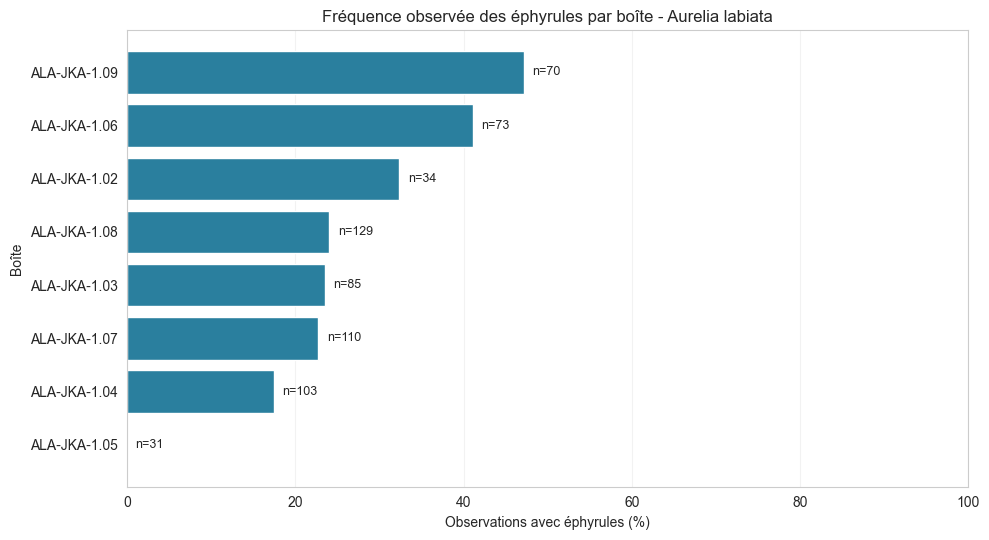

In [5]:
if not pivot_data.empty:
    box_summary = (
        pivot_data.assign(has_ephyrae=(pivot_data['ephyrae'] > 0).astype(int))
        .groupby('box')
        .agg(
            observation_count=('has_ephyrae', 'size'),
            ephyrae_observation_rate=('has_ephyrae', 'mean'),
        )
        .sort_values('ephyrae_observation_rate')
    )

    fig, ax = plt.subplots(figsize=(10, 5.5))
    bars = ax.barh(
        box_summary.index,
        box_summary['ephyrae_observation_rate'] * 100,
        color='#2A7F9E',
    )
    ax.set_xlabel('Observations avec éphyrules (%)')
    ax.set_ylabel('Boîte')
    ax.set_title(f'Fréquence observée des éphyrules par boîte - {TARGET_SPECIES}')
    ax.set_xlim(0, max(100, box_summary['ephyrae_observation_rate'].max() * 110))
    ax.grid(axis='x', alpha=0.25)
    ax.grid(axis='y', visible=False)

    for bar, count in zip(bars, box_summary['observation_count']):
        ax.text(
            bar.get_width() + 1,
            bar.get_y() + bar.get_height() / 2,
            f'n={count}',
            va='center',
            fontsize=9,
        )

    plt.tight_layout()
    save_figure(
        fig,
        f'ml_prediction_ephyrae_rate_by_box_{safe_filename(TARGET_SPECIES)}.png',
    )
    plt.show()
else:
    print('No box comparison available')


## 5. Create features for ML model

In [6]:
if not pivot_data.empty:
    def create_features(df, events_dict):
        """Create features for ML: polyp trend, temperature, seasonality, events."""
        ml_df = df.copy()
        ml_df = ml_df.sort_values(['box', 'file_year', 'week_index'])
        
        # Target: ephyrae present (1) or not (0)
        ml_df['ephyrae_target'] = (ml_df['ephyrae'] > 0).astype(int)
        ml_df['polyp_count'] = ml_df['polyps']
        ml_df['week_of_year'] = ml_df['week_index'] % 52
        
        # Rolling stats by box
        ml_df['polyps_rolling_mean_4w'] = (
            ml_df.groupby('box')['polyp_count']
            .transform(lambda x: x.rolling(window=4, min_periods=1).mean())
        )
        
        ml_df['polyps_rolling_std_4w'] = (
            ml_df.groupby('box')['polyp_count']
            .transform(lambda x: x.rolling(window=4, min_periods=1).std())
        )
        ml_df['polyps_rolling_std_4w'].fillna(0, inplace=True)
        
        # Event indicator
        ml_df['has_recent_event'] = (
            ml_df.apply(
                lambda row: events_dict.get((row['species'], row['week_of_year'], int(row['file_year'])), 0),
                axis=1
            )
        )
        return ml_df
    
    ml_ready = create_features(pivot_data, events)
    
    print('✓ Features created:')
    display(ml_ready[[
        'box', 'file_year', 'week_index', 'polyp_count', 'temperature',
        'ephyrae', 'ephyrae_target', 'week_of_year', 'polyps_rolling_mean_4w',
        'polyps_rolling_std_4w', 'has_recent_event'
    ]].head(15))
    
    print(f'\nTarget distribution:')
    print(ml_ready['ephyrae_target'].value_counts(dropna=False))
else:
    ml_ready = pd.DataFrame()
    print('No features to create')

✓ Features created:


normalized_measurement_type,box,file_year,week_index,polyp_count,temperature,ephyrae,ephyrae_target,week_of_year,polyps_rolling_mean_4w,polyps_rolling_std_4w,has_recent_event
0,ALA-JKA-1.02,2020,1,200.0,5.0,200.0,1,1,200.0,NaN,0
1,ALA-JKA-1.02,2020,2,200.0,5.0,200.0,1,2,200.0,0.0,0
2,ALA-JKA-1.02,2020,3,200.0,5.0,200.0,1,3,200.0,0.0,0
3,ALA-JKA-1.02,2020,4,200.0,5.0,200.0,1,4,200.0,0.0,0
4,ALA-JKA-1.02,2020,5,200.0,5.0,200.0,1,5,200.0,0.0,0
5,ALA-JKA-1.02,2020,6,200.0,5.0,200.0,1,6,200.0,0.0,0
6,ALA-JKA-1.02,2020,7,200.0,5.0,200.0,1,7,200.0,0.0,0
7,ALA-JKA-1.02,2020,8,200.0,5.0,200.0,1,8,200.0,0.0,0
8,ALA-JKA-1.02,2020,9,200.0,5.0,200.0,1,9,200.0,0.0,0
9,ALA-JKA-1.02,2020,10,200.0,5.0,50.0,1,10,200.0,0.0,0



Target distribution:
ephyrae_target
0    467
1    168
Name: count, dtype: int64


## 6. Prepare training data

In [7]:
if not ml_ready.empty:
    train_data = ml_ready.dropna(subset=[
        'polyp_count', 'temperature', 'ephyrae_target',
        'polyps_rolling_mean_4w', 'polyps_rolling_std_4w'
    ]).copy()
    
    print(f'✓ Training rows available: {len(train_data)}')
    print(f'\nTarget balance:')
    print(train_data['ephyrae_target'].value_counts())
    print(f'Percentage with ephyrae: {train_data["ephyrae_target"].mean()*100:.1f}%')
    
    FEATURE_COLS = [
        'polyp_count',
        'temperature',
        'week_of_year',
        'polyps_rolling_mean_4w',
        'polyps_rolling_std_4w',
        'has_recent_event'
    ]
    
    X = train_data[FEATURE_COLS].copy()
    y = train_data['ephyrae_target'].copy()
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled = pd.DataFrame(X_scaled, columns=FEATURE_COLS, index=X.index)
    
    print(f'\nFeature correlation with target:')
    corr_with_target = pd.concat([X_scaled, y], axis=1).corr()['ephyrae_target'].drop('ephyrae_target').sort_values(ascending=False)
    display(corr_with_target)
else:
    train_data = pd.DataFrame()
    print('No training data available')

✓ Training rows available: 627

Target balance:
ephyrae_target
0    460
1    167
Name: count, dtype: int64
Percentage with ephyrae: 26.6%

Feature correlation with target:


polyps_rolling_mean_4w    0.083359
polyp_count               0.073896
polyps_rolling_std_4w    -0.047588
week_of_year             -0.072915
temperature              -0.488261
has_recent_event               NaN
Name: ephyrae_target, dtype: float64

## 7. Train classification model

In [8]:
if not train_data.empty:
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f'✓ Training set: {len(X_train)} samples')
    print(f'✓ Test set: {len(X_test)} samples')
    print(f'Train target balance: {y_train.mean():.1%} with ephyrae')
    print(f'Test target balance: {y_test.mean():.1%} with ephyrae')
    
    print('\nTraining GradientBoostingClassifier...')
    model = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
        verbose=0
    )
    
    model.fit(X_train, y_train)
    print('✓ Model trained!')
    
    cv_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='roc_auc')
    print(f'\n✓ Cross-validation ROC-AUC: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})')
else:
    print('No model to train')

✓ Training set: 501 samples
✓ Test set: 126 samples
Train target balance: 26.5% with ephyrae
Test target balance: 27.0% with ephyrae

Training GradientBoostingClassifier...


✓ Model trained!



✓ Cross-validation ROC-AUC: 0.817 (+/- 0.070)


## 8. Evaluate model

In [9]:
if not train_data.empty:
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    y_pred_proba_test = model.predict_proba(X_test)[:, 1]
    
    train_accuracy = (y_pred_train == y_train).mean()
    test_accuracy = (y_pred_test == y_test).mean()
    test_auc = roc_auc_score(y_test, y_pred_proba_test)
    
    print(f'Train Accuracy: {train_accuracy:.3f}')
    print(f'Test Accuracy: {test_accuracy:.3f}')
    print(f'Test ROC-AUC: {test_auc:.3f}')
    
    print(f'\nClassification Report (Test Set):')
    print(classification_report(y_test, y_pred_test, target_names=['No Ephyrae', 'Ephyrae']))
    
    cm = confusion_matrix(y_test, y_pred_test)
    print(f'\nConfusion Matrix:')
    print(cm)

Train Accuracy: 0.892
Test Accuracy: 0.833
Test ROC-AUC: 0.840

Classification Report (Test Set):
              precision    recall  f1-score   support

  No Ephyrae       0.87      0.91      0.89        92
     Ephyrae       0.72      0.62      0.67        34

    accuracy                           0.83       126
   macro avg       0.80      0.77      0.78       126
weighted avg       0.83      0.83      0.83       126


Confusion Matrix:
[[84  8]
 [13 21]]


### 8.1 Confusion matrix

The confusion matrix shows the number of correct and incorrect classifications.
It is easier to interpret than accuracy alone because the observations with ephyrae
are less frequent than the observations without ephyrae.


Figure saved: notebooks\figures\ml_prediction_confusion_matrix_aurelia_labiata.png


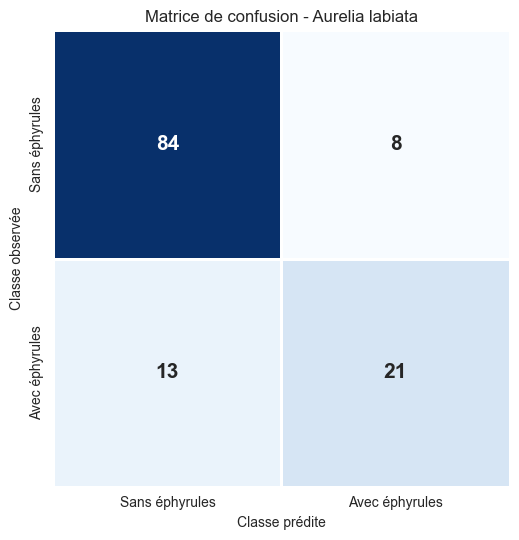

In [10]:
if not train_data.empty:
    fig, ax = plt.subplots(figsize=(6.8, 5.5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        square=True,
        linewidths=1,
        linecolor='white',
        xticklabels=['Sans éphyrules', 'Avec éphyrules'],
        yticklabels=['Sans éphyrules', 'Avec éphyrules'],
        ax=ax,
        annot_kws={'size': 15, 'weight': 'bold'},
    )
    ax.set_xlabel('Classe prédite')
    ax.set_ylabel('Classe observée')
    ax.set_title(f'Matrice de confusion - {TARGET_SPECIES}')
    plt.tight_layout()
    save_figure(
        fig,
        f'ml_prediction_confusion_matrix_{safe_filename(TARGET_SPECIES)}.png',
    )
    plt.show()
else:
    print('No confusion matrix available')


## 9. Feature importance

Feature Importance:


,feature,importance
1,temperature,0.468914
2,week_of_year,0.437677
3,polyps_rolling_mean_4w,0.060965
4,polyps_rolling_std_4w,0.020351
0,polyp_count,0.012093
5,has_recent_event,0.000000


Figure saved: notebooks\figures\ml_prediction_feature_importance_aurelia_labiata.png


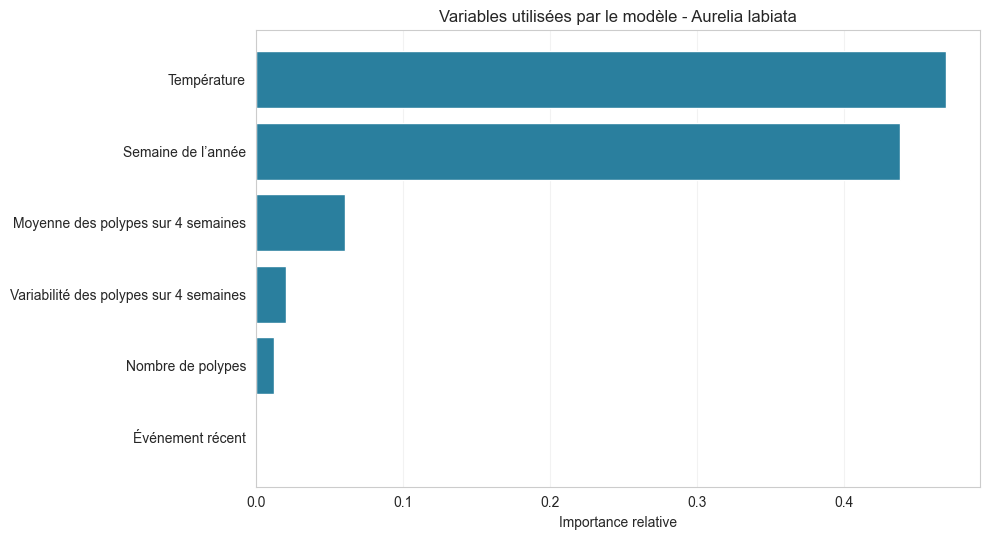

In [11]:
if not train_data.empty:
    feature_importance = pd.DataFrame({
        'feature': FEATURE_COLS,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=True)

    feature_labels = {
        'polyp_count': 'Nombre de polypes',
        'temperature': 'Température',
        'week_of_year': 'Semaine de l’année',
        'polyps_rolling_mean_4w': 'Moyenne des polypes sur 4 semaines',
        'polyps_rolling_std_4w': 'Variabilité des polypes sur 4 semaines',
        'has_recent_event': 'Événement récent',
    }

    print('Feature Importance:')
    display(feature_importance.sort_values('importance', ascending=False))

    fig, ax = plt.subplots(figsize=(10, 5.5))
    ax.barh(
        feature_importance['feature'].map(feature_labels),
        feature_importance['importance'],
        color='#2A7F9E',
    )
    ax.set_xlabel('Importance relative')
    ax.set_title(f'Variables utilisées par le modèle - {TARGET_SPECIES}')
    ax.grid(axis='x', alpha=0.25)
    ax.grid(axis='y', visible=False)
    plt.tight_layout()
    save_figure(
        fig,
        f'ml_prediction_feature_importance_{safe_filename(TARGET_SPECIES)}.png',
    )
    plt.show()
else:
    print('No feature importance available')

## 10. ROC Curve

Figure saved: notebooks\figures\ml_prediction_roc_curve_aurelia_labiata.png


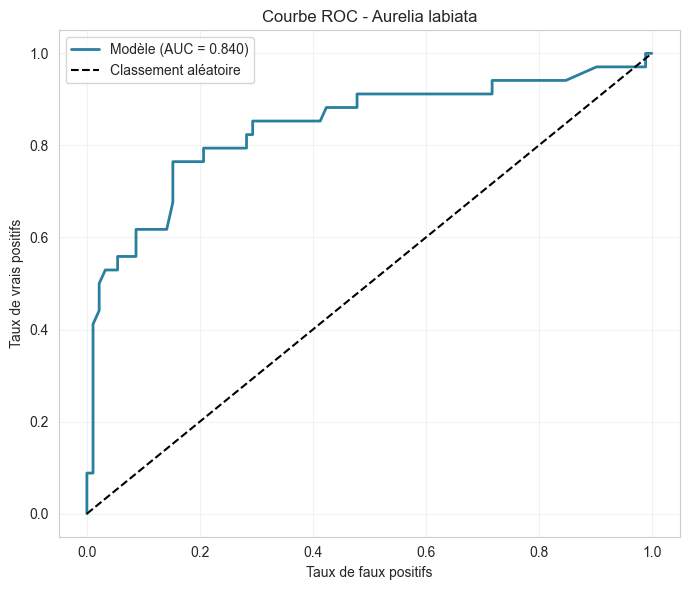

In [12]:
if not train_data.empty:
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_test)

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(fpr, tpr, label=f'Modèle (AUC = {test_auc:.3f})', lw=2, color='#2A7F9E')
    ax.plot([0, 1], [0, 1], 'k--', label='Classement aléatoire')
    ax.set_xlabel('Taux de faux positifs')
    ax.set_ylabel('Taux de vrais positifs')
    ax.set_title(f'Courbe ROC - {TARGET_SPECIES}')
    ax.legend()
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    save_figure(
        fig,
        f'ml_prediction_roc_curve_{safe_filename(TARGET_SPECIES)}.png',
    )
    plt.show()
else:
    print('No ROC curve available')

### 10.1 Precision-recall curve

The precision-recall curve focuses on the observations with ephyrae. It is useful
here because this class is less frequent. The horizontal reference corresponds to
the share of positive observations in the test set.


Figure saved: notebooks\figures\ml_prediction_precision_recall_aurelia_labiata.png


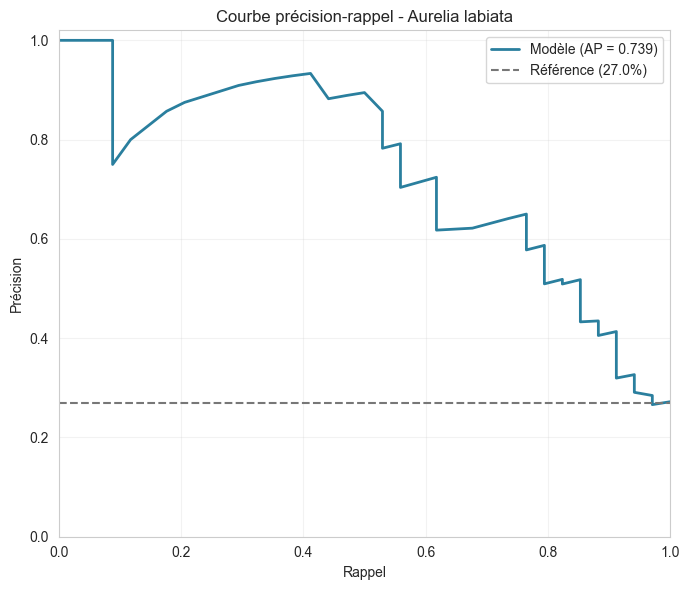

In [13]:
if not train_data.empty:
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_test)
    average_precision = average_precision_score(y_test, y_pred_proba_test)
    positive_rate = y_test.mean()

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(
        recall,
        precision,
        color='#2A7F9E',
        linewidth=2,
        label=f'Modèle (AP = {average_precision:.3f})',
    )
    ax.axhline(
        positive_rate,
        color='#777777',
        linestyle='--',
        label=f'Référence ({positive_rate:.1%})',
    )
    ax.set_xlabel('Rappel')
    ax.set_ylabel('Précision')
    ax.set_title(f'Courbe précision-rappel - {TARGET_SPECIES}')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.legend()
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    save_figure(
        fig,
        f'ml_prediction_precision_recall_{safe_filename(TARGET_SPECIES)}.png',
    )
    plt.show()
else:
    print('No precision-recall curve available')


### 10.2 Predicted probability distribution

This figure compares the probabilities assigned to observations with and without
ephyrae. A large overlap between both distributions shows that several cases remain
difficult to separate.


Figure saved: notebooks\figures\ml_prediction_probability_distribution_aurelia_labiata.png


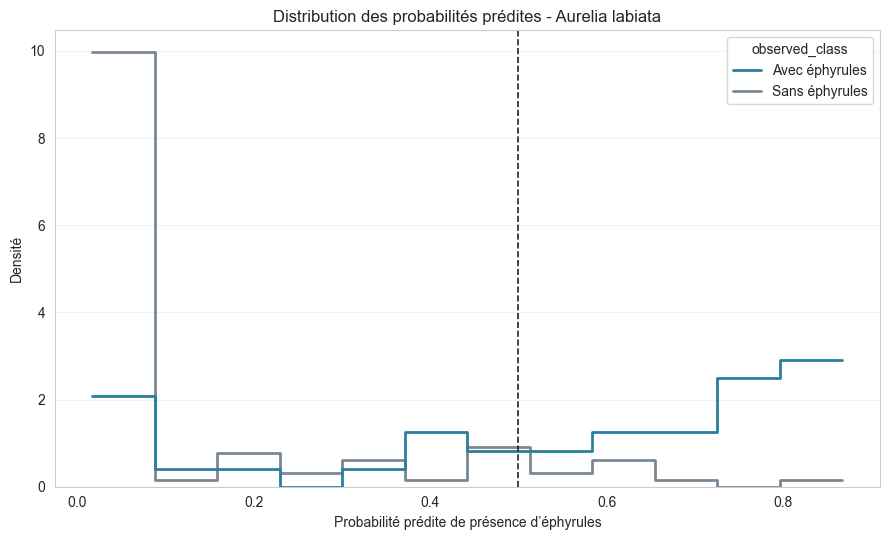

In [14]:
if not train_data.empty:
    probability_results = pd.DataFrame({
        'observed_class': np.where(
            y_test.to_numpy() == 1,
            'Avec éphyrules',
            'Sans éphyrules',
        ),
        'predicted_probability': y_pred_proba_test,
    })

    fig, ax = plt.subplots(figsize=(9, 5.5))
    sns.histplot(
        data=probability_results,
        x='predicted_probability',
        hue='observed_class',
        bins=12,
        stat='density',
        common_norm=False,
        element='step',
        fill=False,
        linewidth=2,
        palette={
            'Sans éphyrules': '#7A8793',
            'Avec éphyrules': '#2A7F9E',
        },
        ax=ax,
    )
    ax.axvline(0.5, color='#222222', linestyle='--', linewidth=1.2)
    ax.set_xlabel('Probabilité prédite de présence d’éphyrules')
    ax.set_ylabel('Densité')
    ax.set_title(f'Distribution des probabilités prédites - {TARGET_SPECIES}')
    ax.grid(axis='y', alpha=0.25)
    ax.grid(axis='x', visible=False)
    plt.tight_layout()
    save_figure(
        fig,
        f'ml_prediction_probability_distribution_{safe_filename(TARGET_SPECIES)}.png',
    )
    plt.show()
else:
    print('No probability distribution available')


## 11. Predictions on recent data (2026)

In [15]:
if not train_data.empty and not ml_ready.empty:
    recent_data = ml_ready[
        (ml_ready['file_year'] == 2026) &
        (ml_ready[FEATURE_COLS].notna().all(axis=1))
    ].copy()
    
    if len(recent_data) > 0:
        X_recent = recent_data[FEATURE_COLS].copy()
        X_recent_scaled = scaler.transform(X_recent)
        
        recent_proba = model.predict_proba(X_recent_scaled)[:, 1]
        recent_pred = model.predict(X_recent_scaled)
        
        recent_data['ephyrae_probability'] = recent_proba
        recent_data['ephyrae_predicted'] = recent_pred
        
        high_risk = recent_data[recent_data['ephyrae_probability'] > 0.5].sort_values(
            'ephyrae_probability', ascending=False
        )[['box', 'week_index', 'polyp_count', 'temperature', 'ephyrae', 'ephyrae_probability']]
        
        print(f'🚨 High-risk observations (probability > 0.5) in 2026:')
        display(high_risk.head(20))
        print(f'\nTotal 2026 predictions: {len(recent_data)}')
        print(f'High-risk count: {len(high_risk)}')
    else:
        print('No complete 2026 data available yet')
else:
    print('Cannot make predictions (no trained model)')

🚨 High-risk observations (probability > 0.5) in 2026:


normalized_measurement_type,box,week_index,polyp_count,temperature,ephyrae,ephyrae_probability
621,ALA-JKA-1.09,6,300.0,5.0,500.0,0.867302
625,ALA-JKA-1.09,10,300.0,5.0,100.0,0.860900
624,ALA-JKA-1.09,9,300.0,5.0,500.0,0.860900
622,ALA-JKA-1.09,7,300.0,5.0,500.0,0.860900
623,ALA-JKA-1.09,8,300.0,5.0,500.0,0.860900
626,ALA-JKA-1.09,11,300.0,5.0,100.0,0.799160
620,ALA-JKA-1.09,5,300.0,5.0,300.0,0.687327
564,ALA-JKA-1.08,19,200.0,10.0,70.0,0.667407
629,ALA-JKA-1.09,14,300.0,5.0,100.0,0.636123
627,ALA-JKA-1.09,12,300.0,5.0,100.0,0.636123



Total 2026 predictions: 38
High-risk count: 17


## 12. Summary

This notebook confirms that a statistical signal can be explored for
**Aurelia labiata**, but the current model is not ready for an operational alert.

The box comparison shows that cultures grouped under the same species do not have
the same observed ephyrae frequency. The current CSV identifies boxes, not validated
strains, so this result must not be interpreted as proof of strain-specific biology.
It shows why future data collection must preserve strain, lineage, temperature
changes, and subculture events.

The next modelling step should avoid one universal model for every culture. Each
strain should have a model trained and validated on its own history when enough
reliable observations are available. Strains with too little data should not receive
an automatic prediction.

The current random split can place observations from the same box or year in both
training and test sets. A future evaluation must use a temporal split or hold out
complete boxes before any result is connected to Polypbase.